### Establecer semilla

In [13]:
import torch
import random
import numpy as np
import os

def set_seed(seed=112):
    # 1. Fija la semilla para el módulo random base de Python
    random.seed(seed)
    
    # 2. Fija la semilla en las variables de entorno (afecta al hash de Python)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. Fija la semilla para NumPy (muy importante si usas Pandas o Scikit-learn)
    np.random.seed(seed)
    
    # 4. Fija la semilla para PyTorch (CPU)
    torch.manual_seed(seed)
    
    # 5. Fija la semilla para PyTorch (GPU / CUDA)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Si usas múltiples GPUs
    
    # 6. Fuerza a CuDNN a usar algoritmos deterministas (solo si usas GPU)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Ejecuta la función al inicio
set_seed(42)

### Carga de archivos .parquet y análisis de distribución de servicios

Se han encontrado 7 archivos Parquet.
¡Hecho! Dataset total con 1,916,757 registros cargados.

--- CLASES DETECTADAS (8) ---
Clase 0: Benigno -> 958,109 registros
Clase 1: Credential Access -> 871,188 registros
Clase 2: Defense Evasion -> 6,048 registros
Clase 3: Exfiltration -> 559 registros
Clase 4: Initial Access -> 10,662 registros
Clase 5: Persistence -> 6,048 registros
Clase 6: Privilege Escalation -> 6,048 registros
Clase 7: Reconnaissance -> 58,095 registros

--- DISTRIBUCIÓN GLOBAL ---
             Cantidad  Porcentaje (%)
service                              
dns            879490           45.88
ssl            860606           44.90
desconocido    154477            8.06
http             9847            0.51
ntp              6628            0.35


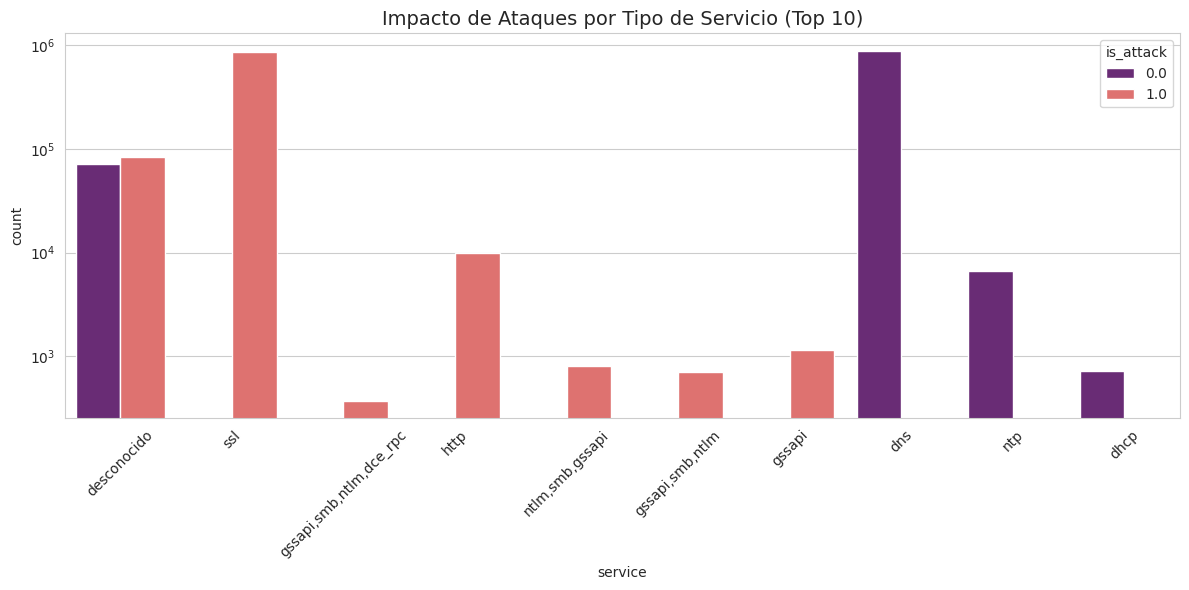

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. LOCALIZACIÓN Y CARGA
archivos_parquet = glob.glob("*.parquet")
print(f"Se han encontrado {len(archivos_parquet)} archivos Parquet.")

lista_df = []
for f in archivos_parquet:
    # Añadimos las columnas numéricas que Zeek nos da para las Edge Features
    columnas_interes = ['service', 'label_tactic', 'src_ip_zeek', 'dest_ip_zeek', 
                        'duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts', 'conn_state', 'missed_bytes', 'ts']
    temp_df = pd.read_parquet(f, columns=columnas_interes)
    lista_df.append(temp_df)

df = pd.concat(lista_df, ignore_index=True)
print(f"¡Hecho! Dataset total con {len(df):,} registros cargados.")

# 2. LIMPIEZA Y CODIFICACIÓN DE ETIQUETAS MULTICLASE
df['service'] = df['service'].replace(['-', ''], 'desconocido').fillna('desconocido')
df['is_attack'] = (df['label_tactic'].fillna('none').str.lower() != 'none').astype(float)

# Limpiamos los nulos y asignamos 'Benigno' a lo que no es ataque
df['label_tactic'] = df['label_tactic'].fillna('Benigno').replace(['none', '-'], 'Benigno')

# Codificamos las tácticas a números (0, 1, 2...)
encoder_tactics = LabelEncoder()
df['target_class'] = encoder_tactics.fit_transform(df['label_tactic'])

num_clases = len(encoder_tactics.classes_)
print(f"\n--- CLASES DETECTADAS ({num_clases}) ---")
for i, clase in enumerate(encoder_tactics.classes_):
    print(f"Clase {i}: {clase} -> {len(df[df['target_class'] == i]):,} registros")

# 3. DIAGNÓSTICO
resumen = pd.DataFrame({
    'Cantidad': df['service'].value_counts(),
    'Porcentaje (%)': (df['service'].value_counts(normalize=True) * 100).round(2)
})
print("\n--- DISTRIBUCIÓN GLOBAL ---")
print(resumen.head())

# 4. VISUALIZACIÓN
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
top_10 = df['service'].value_counts().head(10).index
df_plot = df[df['service'].isin(top_10)]

sns.countplot(data=df_plot, x='service', hue='is_attack', palette='magma')
plt.title('Impacto de Ataques por Tipo de Servicio (Top 10)', fontsize=14)
plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Engineering (Nodos Inductivos y Aristas)

Para que el modelo sea verdaderamente inductivo y agnóstico a la IP, las características iniciales de los nodos (X) deben ser estadísticas de comportamiento.

In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("1. Procesando Características de las Aristas (Edge Features Avanzadas)...")

# --- INGENIERÍA DE CARACTERÍSTICAS TEMPORALES ---
print("Calculando delta temporal para detectar Persistencia (Beaconing)...")
# Ordenamos por IP Origen, IP Destino y Timestamp (ts)
df = df.sort_values(by=['src_ip_zeek', 'dest_ip_zeek', 'ts'])
# Calculamos la diferencia de tiempo con la conexión inmediatamente anterior
df['time_since_last_conn'] = df.groupby(['src_ip_zeek', 'dest_ip_zeek'])['ts'].diff().fillna(0.0)

# 1. Añadimos variable temporal y missed_bytes
edge_cols = ['duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts', 'missed_bytes', 'time_since_last_conn']
df[edge_cols] = df[edge_cols].fillna(0)

# 2. One-Hot Encoding del estado de la conexión
df['conn_state'] = df['conn_state'].fillna('OTH')
conn_state_dummies = pd.get_dummies(df['conn_state'], prefix='state').astype(float)

# 3. Concatenamos numéricas y categóricas
edge_features_df = pd.concat([df[edge_cols], conn_state_dummies], axis=1)

# 4. Estandarizamos (vital porque la columna temporal puede tener valores muy dispares)
scaler_edges = StandardScaler()
edge_features_np = scaler_edges.fit_transform(edge_features_df.values)

print(f"-> Aristas procesadas. Nuevas dimensiones de Edge Features: {edge_features_np.shape[1]} columnas")
print("2. Procesando Características de los Nodos (Node Features Inductivas)...")
ips_unicas = pd.unique(df[['src_ip_zeek', 'dest_ip_zeek']].values.ravel('K'))

# USO DE NAMED AGGREGATION (Soluciona el error de las columnas)
# Calculamos estadísticas cuando la IP actúa como ORIGEN (Out)
out_stats = df.groupby('src_ip_zeek').agg(
    out_bytes_mean=('orig_bytes', 'mean'),
    out_pkts_mean=('orig_pkts', 'mean'),
    out_degree=('orig_bytes', 'count') # El conteo de conexiones
)

# Calculamos estadísticas cuando la IP actúa como DESTINO (In)
in_stats = df.groupby('dest_ip_zeek').agg(
    in_bytes_mean=('resp_bytes', 'mean'),
    in_pkts_mean=('resp_pkts', 'mean'),
    in_degree=('resp_bytes', 'count')
)

node_df = pd.DataFrame(index=ips_unicas)
node_df = node_df.join(out_stats).join(in_stats).fillna(0)

scaler_nodes = StandardScaler()
node_features_np = scaler_nodes.fit_transform(node_df.values)

print(f"-> Nodos procesados con éxito: {len(ips_unicas):,}")

1. Procesando Características de las Aristas (Edge Features Avanzadas)...
Calculando delta temporal para detectar Persistencia (Beaconing)...
-> Aristas procesadas. Nuevas dimensiones de Edge Features: 14 columnas
2. Procesando Características de los Nodos (Node Features Inductivas)...
-> Nodos procesados con éxito: 357


### Construcción del Grafo en PyTorch

In [16]:
import torch

print("Construyendo matriz de adyacencia...")
# Codificamos las IPs a índices numéricos (0 a N)
encoder = LabelEncoder()
encoder.fit(ips_unicas)
df['src_id'] = encoder.transform(df['src_ip_zeek'])
df['dst_id'] = encoder.transform(df['dest_ip_zeek'])

# 1. Matriz de Adyacencia Global (edge_index) [2, num_aristas]
origen = torch.tensor(df['src_id'].values, dtype=torch.long)
destino = torch.tensor(df['dst_id'].values, dtype=torch.long)
edge_index_total = torch.stack([origen, destino], dim=0)

# 2. Tensores de Características (X) y Aristas (Edge_Attr)
x_nodos = torch.tensor(node_features_np, dtype=torch.float)
edge_attr_total = torch.tensor(edge_features_np, dtype=torch.float)

# 3. Etiquetas (Target multiclase)
# IMPORTANTE: CrossEntropyLoss requiere que las etiquetas sean 'long' (enteros)
y_total = torch.tensor(df['target_class'].values, dtype=torch.long)
edge_services = df['service'].values

print(f"Tensor X (Nodos): {x_nodos.shape}")
print(f"Tensor edge_index (Topología): {edge_index_total.shape}")

Construyendo matriz de adyacencia...
Tensor X (Nodos): torch.Size([357, 6])
Tensor edge_index (Topología): torch.Size([2, 1916757])


### Enrutador y Partición Estratificada Train/Test

In [17]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Estratificación
df['stratify_key'] = df['service'] + '_' + df['is_attack'].astype(int).astype(str)
conteo_clases = df['stratify_key'].value_counts()
clases_validas = conteo_clases[conteo_clases > 1].index

indices_validos = df.index[df['stratify_key'].isin(clases_validas)].tolist()
idx_train, idx_test = train_test_split(
    indices_validos, 
    test_size=0.20, 
    random_state=42, 
    stratify=df.loc[indices_validos, 'stratify_key']
)

train_mask = torch.zeros(len(df), dtype=torch.bool)
test_mask = torch.zeros(len(df), dtype=torch.bool)
train_mask[idx_train] = True
test_mask[idx_test] = True

# 2. SEPARACIÓN DEL COMITÉ (Basado en el EDA)
servicios = df['service'].values
is_ataque = df['is_attack'].values

# Definimos 4 grupos lógicos ahora
mask_web = np.isin(servicios, ['ssl', 'http'])
mask_infra = np.isin(servicios, ['dns', 'ntp', 'dhcp'])
# NUEVO EXPERTO: Tráfico de Autenticación y Windows
mask_auth = np.isin(servicios, ['smb', 'gssapi', 'ntlm', 'dce_rpc', 'gssapi,smb,ntlm', 'smb,dce_rpc,ntlm,gssapi', 'ntlm,dce_rpc,smb,gssapi']) 
mask_gen = ~(mask_web | mask_infra | mask_auth) # El resto (desconocido, ftp, etc.)

# --- SOLUCIÓN A LA VARIANZA (El truco del Data Leakage) ---
# Como Web es 100% ataque, necesitamos inyectarle algunos benignos para entrenar.
# Como Infra es 100% benigno, necesitamos inyectarle ataques para entrenar.
# Tomaremos prestados ejemplos del grupo 'Generalista' que sí está balanceado.

benignos_disponibles = mask_gen & (is_ataque == 0)
ataques_disponibles = mask_gen & (is_ataque == 1)

# Máscaras de Entrenamiento para los Expertos (Inyección de varianza)
mask_train_web = (mask_web | benignos_disponibles)
mask_train_infra = (mask_infra | ataques_disponibles)
mask_train_auth = (mask_auth | benignos_disponibles) # Necesita ejemplos benignos

# Convertimos a tensores para PyTorch (Y aplicamos el split de train/test)
train_mask_web = torch.tensor(mask_train_web, dtype=torch.bool) & train_mask
train_mask_infra = torch.tensor(mask_train_infra, dtype=torch.bool) & train_mask
train_mask_auth = torch.tensor(mask_train_auth, dtype=torch.bool) & train_mask
train_mask_gen = torch.tensor(mask_gen, dtype=torch.bool) & train_mask

# --- UNDERSAMPLING PARA EL ENTRENAMIENTO ---
# Extraemos los índices donde hay Benigno (0) o Credential Access (1) EN EL CONJUNTO DE TRAIN
idx_mayoritarias = np.where(((is_ataque == 0) | (df['target_class'].values == 1)) & train_mask.numpy())[0]

# Decidimos cuántos queremos "apagar" (ej. descartamos el 75% para aligerar el ruido)
porcentaje_descarte = 0.75
num_descarte = int(len(idx_mayoritarias) * porcentaje_descarte)

# Elegimos aleatoriamente cuáles apagar
np.random.seed(42)
idx_a_apagar = np.random.choice(idx_mayoritarias, num_descarte, replace=False)

# Creamos un tensor de máscara de "apagado"
mascara_apagado = torch.zeros(len(df), dtype=torch.bool)
mascara_apagado[idx_a_apagar] = True

# Se lo restamos a los tensores de entrenamiento de los expertos
train_mask_web = train_mask_web & ~mascara_apagado
train_mask_infra = train_mask_infra & ~mascara_apagado
train_mask_auth = train_mask_auth & ~mascara_apagado
train_mask_gen = train_mask_gen & ~mascara_apagado

print(f"Undersampling aplicado: Se han silenciado {num_descarte:,} ejemplos mayoritarios para el entrenamiento.")

test_mask_web = torch.tensor(mask_web, dtype=torch.bool) & test_mask
test_mask_infra = torch.tensor(mask_infra, dtype=torch.bool) & test_mask
test_mask_auth = torch.tensor(mask_auth, dtype=torch.bool) & test_mask
test_mask_gen = torch.tensor(mask_gen, dtype=torch.bool) & test_mask

print("\n--- DISTRIBUCIÓN DEL COMITÉ PARA ENTRENAMIENTO ---")
print(f"Experto Web (con varianza inyectada): {train_mask_web.sum().item():,} aristas")
print(f"Experto Infra (con varianza inyectada): {train_mask_infra.sum().item():,} aristas")
print(f"Experto Generalista: {train_mask_gen.sum().item():,} aristas")

Undersampling aplicado: Se han silenciado 1,097,493 ejemplos mayoritarios para el entrenamiento.

--- DISTRIBUCIÓN DEL COMITÉ PARA ENTRENAMIENTO ---
Experto Web (con varianza inyectada): 191,236 aristas
Experto Infra (con varianza inyectada): 242,768 aristas
Experto Generalista: 80,039 aristas


### Arquitectura GraphSAGE (El Modelo)

In [18]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GATConv

class AdvancedEdgeExpert(torch.nn.Module):
    def __init__(self, node_in_channels, edge_in_channels, hidden_channels, out_classes, conv_type='SAGE', dropout_rate=0.3):
        super(AdvancedEdgeExpert, self).__init__()
        self.conv_type = conv_type
        
        # --- DIVERSIDAD ARQUITECTÓNICA ---
        if conv_type == 'SAGE':
            self.conv1 = SAGEConv(node_in_channels, hidden_channels)
            self.conv2 = SAGEConv(hidden_channels, hidden_channels)
            self.conv3 = SAGEConv(hidden_channels, hidden_channels) # NUEVA CAPA
        elif conv_type == 'GAT':
            # GAT usa cabezales de atención (heads). Multiplican la salida, 
            # así que dividimos los canales para mantener la dimensión final igual.
            heads = 4
            self.conv1 = GATConv(node_in_channels, hidden_channels // heads, heads=heads)
            self.conv2 = GATConv(hidden_channels, hidden_channels // heads, heads=heads) # AHORA MANTIENE HEADS
            self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1) # NUEVA CAPA FINAL

        
        # --- PERCEPTRÓN DINÁMICO ---
        clf_input_dim = (hidden_channels * 2) + edge_in_channels
        self.edge_classifier = nn.Sequential(
            nn.Linear(clf_input_dim, hidden_channels),
            nn.BatchNorm1d(hidden_channels), # Batch Normalization ayuda mucho a la convergencia
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Linear(hidden_channels // 2, out_classes) 
        )

    def forward(self, x, edge_index_msg, edge_index_pred, edge_attr_pred):
        x = self.conv1(x, edge_index_msg)
        x = F.relu(x)
        x = self.conv2(x, edge_index_msg)
        x = F.relu(x)
        x = self.conv3(x, edge_index_msg)
        
        src = edge_index_pred[0]
        dst = edge_index_pred[1]
        
        edge_features = torch.cat([x[src], x[dst], edge_attr_pred], dim=-1)
        
        return self.edge_classifier(edge_features)

### Bucle de Entrenamiento

In [19]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando en: {device}\n")

# --- 1. ETIQUETAS Y MÁSCARAS DE DOS FASES ---
y_binario = torch.tensor(df['is_attack'].astype(int).values, dtype=torch.long).to(device)
is_ataque_tensor = torch.tensor(df['is_attack'].values == 1, dtype=torch.bool)

# Para la Fase 2 (Multiclase) aislamos los ataques. 
# Inyectamos ataques variados a todos los expertos para que puedan comparar tácticas internamente
ataques_inyeccion = torch.tensor(ataques_disponibles, dtype=torch.bool) & train_mask

train_mask_web_ataques = (torch.tensor(mask_web, dtype=torch.bool) & train_mask & is_ataque_tensor) | ataques_inyeccion
train_mask_infra_ataques = (torch.tensor(mask_infra, dtype=torch.bool) & train_mask & is_ataque_tensor) | ataques_inyeccion
train_mask_auth_ataques = (torch.tensor(mask_auth, dtype=torch.bool) & train_mask & is_ataque_tensor) | ataques_inyeccion
train_mask_gen_ataques = torch.tensor(mask_gen, dtype=torch.bool) & train_mask & is_ataque_tensor


# --- 2. COMITÉ FASE 1: BINARIO (El Filtro Portero) ---
# Predicen 2 clases (out_classes=2): 0 o 1
model_bin_web = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, 2, 'SAGE', 0.3).to(device)
model_bin_infra = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 64, 2, 'SAGE', 0.2).to(device)
model_bin_auth = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, 2, 'GAT', 0.4).to(device)
model_bin_gen = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 256, 2, 'GAT', 0.5).to(device)

opt_bin_web = torch.optim.Adam(model_bin_web.parameters(), lr=0.005)
opt_bin_infra = torch.optim.Adam(model_bin_infra.parameters(), lr=0.005)
opt_bin_auth = torch.optim.Adam(model_bin_auth.parameters(), lr=0.003)
opt_bin_gen = torch.optim.Adam(model_bin_gen.parameters(), lr=0.001)

# --- 3. COMITÉ FASE 2: MULTICLASE (El Analista Forense - Soft Voting Ensemble) ---
# WEB: Se queda en SAGE (Topología sencilla)
model_multi_web = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, num_clases, 'SAGE', 0.3).to(device)
opt_multi_web = torch.optim.Adam(model_multi_web.parameters(), lr=0.005)

# INFRA: SAGE + GAT
model_multi_infra_sage = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 64, num_clases, 'SAGE', 0.2).to(device)
model_multi_infra_gat = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 64, num_clases, 'GAT', 0.2).to(device)
opt_multi_infra_sage = torch.optim.Adam(model_multi_infra_sage.parameters(), lr=0.005)
opt_multi_infra_gat = torch.optim.Adam(model_multi_infra_gat.parameters(), lr=0.001)

# AUTH: SAGE + GAT
model_multi_auth_sage = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, num_clases, 'SAGE', 0.4).to(device)
model_multi_auth_gat = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, num_clases, 'GAT', 0.4).to(device)
opt_multi_auth_sage = torch.optim.Adam(model_multi_auth_sage.parameters(), lr=0.003)
opt_multi_auth_gat = torch.optim.Adam(model_multi_auth_gat.parameters(), lr=0.001)

# GENERALISTA: SAGE + GAT
model_multi_gen_sage = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 256, num_clases, 'SAGE', 0.5).to(device)
model_multi_gen_gat = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 256, num_clases, 'GAT', 0.5).to(device)
opt_multi_gen_sage = torch.optim.Adam(model_multi_gen_sage.parameters(), lr=0.001)
opt_multi_gen_gat = torch.optim.Adam(model_multi_gen_gat.parameters(), lr=0.001)

# Movemos los datos globales a la memoria de la GPU
x_nodos = x_nodos.to(device)
edge_index_total = edge_index_total.to(device)

# --- 1. DEFINICIÓN DE FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma # Gamma controla cuánto se ignoran los ejemplos fáciles (2.0 es el estándar de la industria)

    def forward(self, inputs, targets):
        # Calculamos la CrossEntropy normal sin reducción
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        # pt es la probabilidad que el modelo le dio a la clase correcta
        pt = torch.exp(-ce_loss)
        # Aplicamos el factor focal: (1 - probabilidad)^gamma
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

def entrenar_experto_jerarquico(nombre, modelo, optimizador, mascara_train, y_target, is_multiclass=False, epochs=300):
    print(f"\n--- Entrenando Experto: {nombre} ---")
    if mascara_train.sum() == 0:
        print("No hay datos para entrenar.")
        return
        
    edge_index_train = edge_index_total[:, mascara_train]
    edge_attr_train = edge_attr_total[mascara_train].to(device)
    y_train = y_target[mascara_train].to(device)
    
    y_train_np = y_train.cpu().numpy()
    clases_unicas = np.unique(y_train_np)
    pesos_array = compute_class_weight('balanced', classes=clases_unicas, y=y_train_np)
    
    # Asignación inteligente de pesos
    # if is_multiclass:
    #     pesos_tensor = torch.zeros(num_clases, dtype=torch.float).to(device)
    #     for i, c in enumerate(clases_unicas):
    #         pesos_tensor[c] = min(pesos_array[i], 12.0) # Clipping moderado para no romper otras clases
        
    #     # Como Benigno ya no está, la táctica predominante será Credential Access
    #     id_cred = encoder_tactics.transform(['Credential Access'])[0]
    #     if id_cred in clases_unicas:
    #         pesos_tensor[id_cred] = 0.5 # Le restamos poder para que no aplaste a la Exfiltración
            
    #     criterion = FocalLoss(weight=pesos_tensor, gamma=2.0)
    if is_multiclass:
        pesos_tensor = torch.zeros(num_clases, dtype=torch.float).to(device)
        for i, c in enumerate(clases_unicas):
            pesos_tensor[c] = min(pesos_array[i], 15.0) # Subimos el techo general a 15.0
        
        # --- ANCLAJE ESTRICTO CONTRA VARIANZA DE SEMILLA ---
        id_privilege = encoder_tactics.transform(['Privilege Escalation'])[0]
        id_defense = encoder_tactics.transform(['Defense Evasion'])[0]
        id_persistence = encoder_tactics.transform(['Persistence'])[0]
        id_exfil = encoder_tactics.transform(['Exfiltration'])[0]
        
        # Obligamos a que las minoritarias tengan un peso contundente, sin importar qué diga scikit-learn
        if id_privilege in clases_unicas: pesos_tensor[id_privilege] = max(pesos_tensor[id_privilege], 15.0)
        if id_defense in clases_unicas: pesos_tensor[id_defense] = max(pesos_tensor[id_defense], 15.0)
        if id_persistence in clases_unicas: pesos_tensor[id_persistence] = max(pesos_tensor[id_persistence], 15.0)
        if id_exfil in clases_unicas: pesos_tensor[id_exfil] = max(pesos_tensor[id_exfil], 20.0)
        
        # --- SUPRESIÓN DEL "CANÍBAL" ---
        id_cred = encoder_tactics.transform(['Credential Access'])[0]
        if id_cred in clases_unicas:
            # Lo bajamos de 0.5 a 0.2. Obligamos a la red a no acomodarse en esta clase.
            pesos_tensor[id_cred] = 0.2 
            
        criterion = FocalLoss(weight=pesos_tensor, gamma=2.0)
    else:
        # En la Fase 1 (Binaria) el problema es mucho más sencillo
        pesos_tensor = torch.zeros(2, dtype=torch.float).to(device)
        for i, c in enumerate(clases_unicas):
            pesos_tensor[c] = min(pesos_array[i], 5.0)
        criterion = FocalLoss(weight=pesos_tensor, gamma=1.0)
        
    modelo.train()
    for epoch in range(epochs):
        optimizador.zero_grad()
        out = modelo(x_nodos, edge_index_total, edge_index_train, edge_attr_train)
        loss = criterion(out, y_train)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
        optimizador.step()
        
        if (epoch+1) % 50 == 0:
            preds = torch.argmax(out, dim=1)
            acc = (preds == y_train).sum().item() / len(y_train)
            print(f'Epoch {epoch+1:03d} | Loss: {loss.item():.4f} | Acc: {acc:.4f}')

# ================= ENTRENAMIENTO EN MASA =================
print(">>> INICIANDO FASE 1 (MODELOS BINARIOS)")
entrenar_experto_jerarquico("BIN. WEB", model_bin_web, opt_bin_web, train_mask_web, y_binario, is_multiclass=False, epochs=150)
entrenar_experto_jerarquico("BIN. INFRA", model_bin_infra, opt_bin_infra, train_mask_infra, y_binario, is_multiclass=False, epochs=150)
entrenar_experto_jerarquico("BIN. AUTH", model_bin_auth, opt_bin_auth, train_mask_auth, y_binario, is_multiclass=False, epochs=200)
entrenar_experto_jerarquico("BIN. GEN", model_bin_gen, opt_bin_gen, train_mask_gen, y_binario, is_multiclass=False, epochs=250)

print("\n>>> INICIANDO FASE 2 (MODELOS MULTICLASE - SAGE + GAT)")
entrenar_experto_jerarquico("MULTI WEB (SAGE)", model_multi_web, opt_multi_web, train_mask_web_ataques, y_total, is_multiclass=True, epochs=400)
entrenar_experto_jerarquico("MULTI INFRA (SAGE)", model_multi_infra_sage, opt_multi_infra_sage, train_mask_infra_ataques, y_total, is_multiclass=True, epochs=700)
entrenar_experto_jerarquico("MULTI INFRA (GAT)", model_multi_infra_gat, opt_multi_infra_gat, train_mask_infra_ataques, y_total, is_multiclass=True, epochs=700)
entrenar_experto_jerarquico("MULTI AUTH (SAGE)", model_multi_auth_sage, opt_multi_auth_sage, train_mask_auth_ataques, y_total, is_multiclass=True, epochs=700)
entrenar_experto_jerarquico("MULTI AUTH (GAT)", model_multi_auth_gat, opt_multi_auth_gat, train_mask_auth_ataques, y_total, is_multiclass=True, epochs=700)
entrenar_experto_jerarquico("MULTI GEN (SAGE)", model_multi_gen_sage, opt_multi_gen_sage, train_mask_gen_ataques, y_total, is_multiclass=True, epochs=700)
entrenar_experto_jerarquico("MULTI GEN (GAT)", model_multi_gen_gat, opt_multi_gen_gat, train_mask_gen_ataques, y_total, is_multiclass=True, epochs=700)

Entrenando en: cuda

>>> INICIANDO FASE 1 (MODELOS BINARIOS)

--- Entrenando Experto: BIN. WEB ---
Epoch 050 | Loss: 0.0000 | Acc: 1.0000
Epoch 100 | Loss: 0.0000 | Acc: 1.0000
Epoch 150 | Loss: 0.0000 | Acc: 1.0000

--- Entrenando Experto: BIN. INFRA ---
Epoch 050 | Loss: 0.0097 | Acc: 0.9959
Epoch 100 | Loss: 0.0005 | Acc: 0.9996
Epoch 150 | Loss: 0.0001 | Acc: 1.0000

--- Entrenando Experto: BIN. AUTH ---
Epoch 050 | Loss: 0.0007 | Acc: 0.9998
Epoch 100 | Loss: 0.0007 | Acc: 0.9998
Epoch 150 | Loss: 0.0007 | Acc: 0.9998
Epoch 200 | Loss: 0.0007 | Acc: 0.9998

--- Entrenando Experto: BIN. GEN ---
Epoch 050 | Loss: 0.0495 | Acc: 0.9870
Epoch 100 | Loss: 0.0368 | Acc: 0.9910
Epoch 150 | Loss: 0.0282 | Acc: 0.9930
Epoch 200 | Loss: 0.0261 | Acc: 0.9946
Epoch 250 | Loss: 0.0258 | Acc: 0.9946

>>> INICIANDO FASE 2 (MODELOS MULTICLASE - SAGE + GAT)

--- Entrenando Experto: MULTI WEB (SAGE) ---
Epoch 050 | Loss: 0.5962 | Acc: 0.9524
Epoch 100 | Loss: 0.5954 | Acc: 0.9590
Epoch 150 | Loss: 0

### Evaluación en el Conjunto de Test

Ejecutando Inferencia en Cascada con Soft Voting...

--- REPORTE DE EVALUACIÓN (CASCADA + SOFT VOTING ENSEMBLE) ---
                      precision    recall  f1-score   support

             Benigno       0.99      1.00      0.99    191573
   Credential Access       1.00      1.00      1.00    174400
     Defense Evasion       0.17      0.52      0.26      1200
        Exfiltration       0.18      0.49      0.26       115
      Initial Access       0.93      0.45      0.61      2157
         Persistence       0.25      0.27      0.26      1193
Privilege Escalation       0.15      0.44      0.22      1222
      Reconnaissance       0.98      0.48      0.64     11492

            accuracy                           0.97    383352
           macro avg       0.58      0.58      0.53    383352
        weighted avg       0.99      0.97      0.98    383352



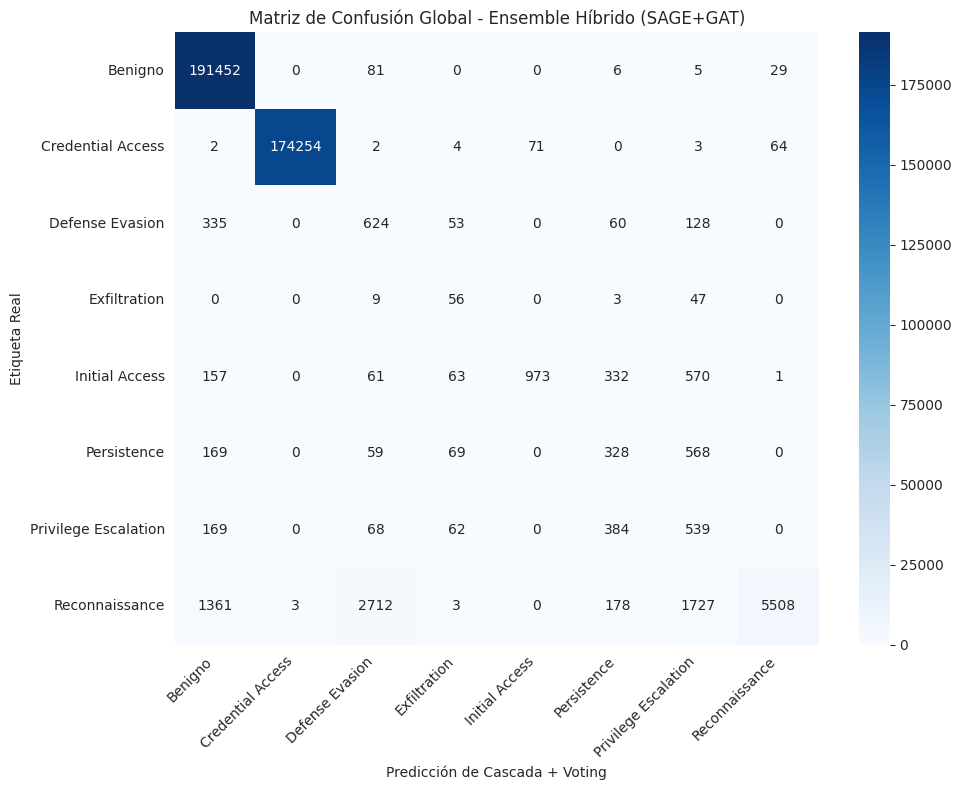

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F

print("Ejecutando Inferencia en Cascada con Soft Voting...")

todas_las_predicciones = []
todas_las_etiquetas = []
id_benigno = encoder_tactics.transform(['Benigno'])[0]

def predecir_cascada_voting(mascara_test, model_bin, lista_modelos_multi):
    if mascara_test.sum() == 0: return
    
    edge_index_test = edge_index_total[:, mascara_test]
    edge_attr_test = edge_attr_total[mascara_test].to(device)
    y_test_real = y_total[mascara_test].to(device)
    
    # 1. Fase Binaria (El Portero)
    model_bin.eval()
    with torch.no_grad():
        out_bin = model_bin(x_nodos, edge_index_total, edge_index_test, edge_attr_test)
        preds_bin = torch.argmax(out_bin, dim=1)
        
    # 2. Fase Multiclase (El Analista - Soft Voting)
    preds_finales = torch.full_like(preds_bin, fill_value=id_benigno)
    idx_ataques = torch.where(preds_bin == 1)[0]
    
    if len(idx_ataques) > 0:
        edge_index_ataques = edge_index_test[:, idx_ataques]
        edge_attr_ataques = edge_attr_test[idx_ataques]
        
        # Tensor para acumular las probabilidades de todos los modelos
        probabilidades_acumuladas = torch.zeros((len(idx_ataques), num_clases)).to(device)
        
        for mod in lista_modelos_multi:
            mod.eval()
            with torch.no_grad():
                out_multi = mod(x_nodos, edge_index_total, edge_index_ataques, edge_attr_ataques)
                # Convertimos logits a probabilidades antes de sumar
                probs = F.softmax(out_multi, dim=1) 
                probabilidades_acumuladas += probs
                
        # Promediamos las probabilidades
        probabilidades_finales = probabilidades_acumuladas / len(lista_modelos_multi)
        
        # IMPEDIMOS MATEMÁTICAMENTE que la fase 2 prediga 'Benigno'
        # Ponemos su probabilidad a 0.0 para que el argmax no lo elija
        probabilidades_finales[:, id_benigno] = 0.0 
        
        preds_multi = torch.argmax(probabilidades_finales, dim=1)
        preds_finales[idx_ataques] = preds_multi
        
    todas_las_predicciones.extend(preds_finales.cpu().numpy())
    todas_las_etiquetas.extend(y_test_real.cpu().numpy())

# Ejecutamos las 4 ramas del enrutador pasando las LISTAS de modelos
predecir_cascada_voting(test_mask_web, model_bin_web, [model_multi_web])
predecir_cascada_voting(test_mask_infra, model_bin_infra, [model_multi_infra_sage, model_multi_infra_gat])
predecir_cascada_voting(test_mask_auth, model_bin_auth, [model_multi_auth_sage, model_multi_auth_gat])
predecir_cascada_voting(test_mask_gen, model_bin_gen, [model_multi_gen_sage, model_multi_gen_gat])

y_true_global = np.array(todas_las_etiquetas)
preds_global = np.array(todas_las_predicciones)

print("\n--- REPORTE DE EVALUACIÓN (CASCADA + SOFT VOTING ENSEMBLE) ---")
clases_presentes = np.unique(np.concatenate((y_true_global, preds_global)))
nombres_clases = encoder_tactics.inverse_transform(clases_presentes)
nombres_clases_list = [str(c) for c in nombres_clases]

print(classification_report(y_true_global, preds_global, labels=clases_presentes, target_names=nombres_clases_list))

cm = confusion_matrix(y_true_global, preds_global, labels=clases_presentes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases_list, yticklabels=nombres_clases_list)
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción de Cascada + Voting')
plt.title('Matriz de Confusión Global - Ensemble Híbrido (SAGE+GAT)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Exportar modelos (con pesos y codificadores)

In [21]:
import joblib
import os
import torch

print("Guardando el Clasificador Jerárquico Híbrido para Producción...")
os.makedirs("modelos_produccion", exist_ok=True)

# 1. Guardamos Modelos FASE 1 (Binarios)
torch.save(model_bin_web.state_dict(), "modelos_produccion/bin_web.pth")
torch.save(model_bin_infra.state_dict(), "modelos_produccion/bin_infra.pth")
torch.save(model_bin_auth.state_dict(), "modelos_produccion/bin_auth.pth")
torch.save(model_bin_gen.state_dict(), "modelos_produccion/bin_gen.pth")

# 2. Guardamos Modelos FASE 2 (Multiclase)
torch.save(model_multi_web.state_dict(), "modelos_produccion/multi_web_sage.pth")
torch.save(model_multi_infra_sage.state_dict(), "modelos_produccion/multi_infra_sage.pth")
torch.save(model_multi_infra_gat.state_dict(), "modelos_produccion/multi_infra_gat.pth")
torch.save(model_multi_auth_sage.state_dict(), "modelos_produccion/multi_auth_sage.pth")
torch.save(model_multi_auth_gat.state_dict(), "modelos_produccion/multi_auth_gat.pth")
torch.save(model_multi_gen_sage.state_dict(), "modelos_produccion/multi_gen_sage.pth")
torch.save(model_multi_gen_gat.state_dict(), "modelos_produccion/multi_gen_gat.pth")

# 3. Guardamos los Scalers y Encoders
joblib.dump(scaler_edges, "modelos_produccion/scaler_edges.pkl")
joblib.dump(scaler_nodes, "modelos_produccion/scaler_nodes.pkl") 
joblib.dump(encoder_tactics, "modelos_produccion/encoder_tactics.pkl")

# 4. Guardamos el Cerebro Histórico de los Nodos
node_df.to_pickle("modelos_produccion/node_features_historicas.pkl")

print("¡Modelos exportados con éxito!")

Guardando el Clasificador Jerárquico Híbrido para Producción...
¡Modelos exportados con éxito!


### Exportar datos de test

In [22]:
print("Exportando el dataset de simulación estricto para Kafka...")

# 1. Recuperamos las filas exactas que fueron asignadas a Test (nunca vistas en Train)
# idx_test contiene los índices matemáticos de la separación estratificada original
df_test_estricto = df.iloc[idx_test].copy()

# 2. (Opcional pero recomendado) Ordenamos cronológicamente el test set 
# para que la simulación en Kafka mantenga la coherencia de la variable 'time_since_last_conn'
df_test_estricto = df_test_estricto.sort_values(by='ts')

# 3. Lo guardamos físicamente en un archivo separado
ruta_dataset_kafka = "modelos_produccion/dataset_simulacion_kafka.parquet"
df_test_estricto.to_parquet(ruta_dataset_kafka, index=False)

print(f"¡Dataset de Kafka exportado! Contiene {len(df_test_estricto):,} conexiones 100% aisladas del entrenamiento.")

Exportando el dataset de simulación estricto para Kafka...


¡Dataset de Kafka exportado! Contiene 383,352 conexiones 100% aisladas del entrenamiento.


### Exportar el resto de datos con las transformaciones realizadas

In [23]:
import json

print("Exportando datos y metadatos para el Data Engineer...")

# 1. Exportar el Dataset Histórico (Todo lo que NO es Test)
# Usamos una máscara booleana para coger lo que no está en idx_test
mascara_test = df.index.isin(idx_test)
df_historico = df[~mascara_test].copy()
df_historico = df_historico.sort_values(by='ts')
df_historico.to_parquet("modelos_produccion/dataset_historico_neo4j.parquet", index=False)

# 2. EXPORTAR EL ORDEN EXACTO DE LAS FEATURES (¡CRÍTICO PARA TU COMPAÑERO!)
# Guardamos los nombres de las columnas que generó tu pd.concat (incluyendo los dummies)
columnas_modelo = list(edge_features_df.columns)
with open("modelos_produccion/columnas_modelo.json", "w") as f:
    json.dump(columnas_modelo, f)

print(f"Dataset histórico exportado: {len(df_historico):,} conexiones.")
print(f"El modelo espera exactamente {len(columnas_modelo)} features en este orden.")

Exportando datos y metadatos para el Data Engineer...
Dataset histórico exportado: 1,533,405 conexiones.
El modelo espera exactamente 14 features en este orden.


### Limpiar caché

In [24]:
import gc
gc.collect()
torch.cuda.empty_cache()